In [41]:
import math
import random
import torch

In [42]:
class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        # backward function for autograd
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        # define the backward function for addition
        def _backward():
            # we use "+=" in order to accumulate gradients in case of multiple paths in the computation graph
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        # define the backward function for multiplication
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __sub__(self, other):
        return self + other * -1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')

        # define the backward function for power
        def _backward():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        # define the backward function for exp
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        # define the backward function for tanh
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    # define the backward method to perform backpropagation using topo sort
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [43]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = Left to Right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


In [44]:
# We will implement the same computation graph as before(basics.ipynb), but using PyTorch's autograd functionality.

# Inputs
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(0.0, requires_grad=True)

# weights
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)

# bias
b = torch.tensor(6.881373587019543, requires_grad=True)

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(f"Output of the neuron: {o.data.item()}")
o.backward()

print(f"Gradient of x1: {x1.grad.item()}")
print(f"Gradient of x2: {x2.grad.item()}")
print(f"Gradient of w1: {w1.grad.item()}")
print(f"Gradient of w2: {w2.grad.item()}")

Output of the neuron: 0.7071067094802856
Gradient of x1: -1.5000003576278687
Gradient of x2: 0.5000001192092896
Gradient of w1: 1.000000238418579
Gradient of w2: 0.0


In [56]:
# A Neuron is a single unit in a neural network that takes multiple inputs, applies 
# weights and bias, and produces an output through an activation function.

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1), label=f'w{i}') for i in range(nin)]
        self.b = Value(random.uniform(-1, 1), label='b')

    def __call__(self, x):
        # w * x + b
        act = sum((xi*wi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()

        return out
    
    def parameters(self):
        return self.w + [self.b]

In [57]:
# A Layer is a collection of neurons
# They are not connected to each other, rather they operate independently on the same input vector. 
# Each neuron in the layer takes the same input vector and produces its own output. 
# The outputs of all neurons in the layer are collected into a list and returned as the output of the layer.

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

In [58]:
# MLP (Multi-Layer Perceptron) is a neural network consisting of multiple layers of neurons.

class MLP:
    # nin is the number of inputs, nouts is a list of layer sizes.
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [59]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
# sz = [3, 4, 4, 1]
# # range(len(nouts)) = range(3) = 0, 1, 2
# Layer(sz[0], sz[1])  # Layer(3, 4) — input layer
# Layer(sz[1], sz[2])  # Layer(4, 4) — hidden layer
# Layer(sz[2], sz[3])  # Layer(4, 1) — output layer
n(x)

Value(data=-0.7887130243317971)

In [62]:
len(n.parameters())
n.parameters()

[Value(data=-0.6922947192372122),
 Value(data=-0.1496984327482065),
 Value(data=0.7197879898641335),
 Value(data=-0.4648103747641421),
 Value(data=-0.9141418725646377),
 Value(data=0.8706278794438194),
 Value(data=-0.762616694330253),
 Value(data=0.32847698806178016),
 Value(data=0.05382215560204773),
 Value(data=-0.46747392133446497),
 Value(data=0.9392354261701361),
 Value(data=-0.41608745869417985),
 Value(data=0.6990865597297364),
 Value(data=0.47924273396136075),
 Value(data=-0.6195573965587531),
 Value(data=-0.6393436413004479),
 Value(data=-0.5074322601271248),
 Value(data=0.43668092909152767),
 Value(data=0.5210402670826715),
 Value(data=-0.7634540708957502),
 Value(data=-0.8266203307434934),
 Value(data=0.6999312048893911),
 Value(data=-0.019316424207103555),
 Value(data=0.3052823050063094),
 Value(data=-0.4149607292431241),
 Value(data=-0.23562540202210802),
 Value(data=0.46026546187216333),
 Value(data=-0.1505018138996299),
 Value(data=-0.9231724970930131),
 Value(data=0.737

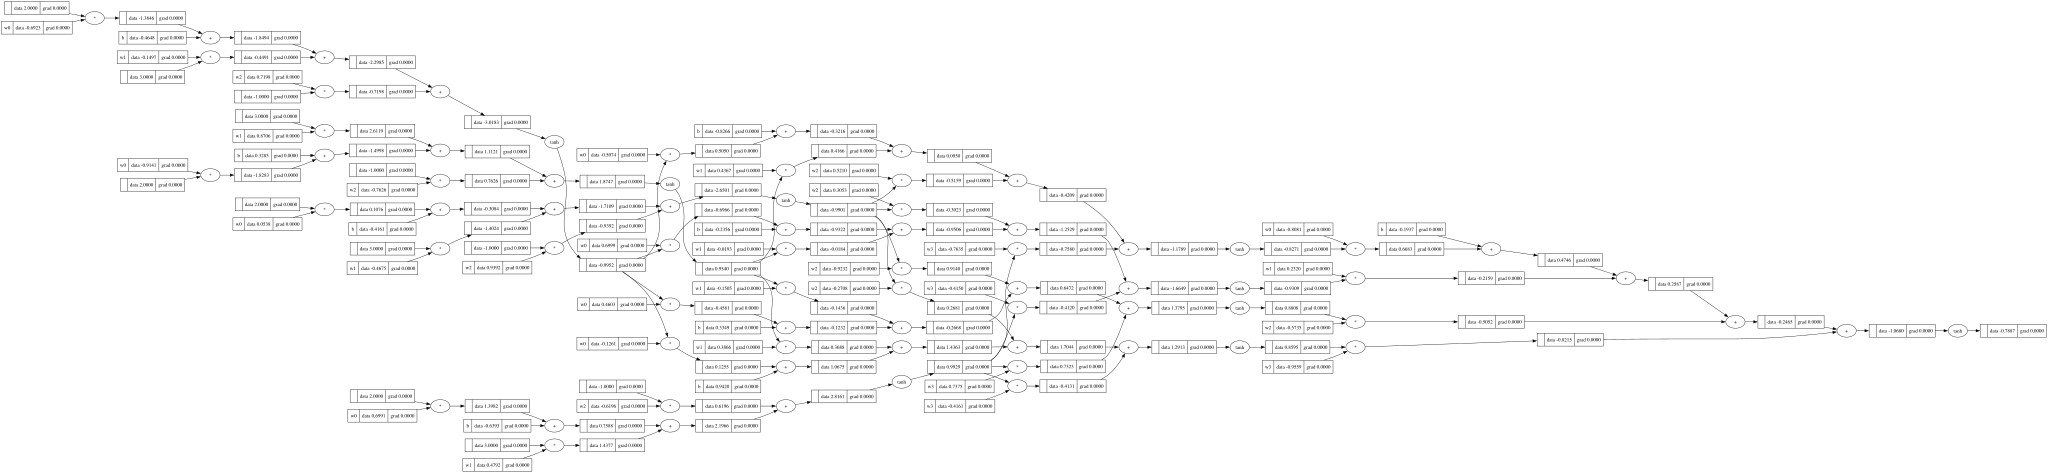

In [63]:
draw_dot(n(x))

In [ ]:
# input to our neural network
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired outputs

ypred = [n(x) for x in xs]
ypred

[Value(data=-0.7887130243317971),
 Value(data=0.004734563318326601),
 Value(data=-0.5686027424687277),
 Value(data=-0.7857021000816532)]

In [ ]:
# Loss is the measure of how well our neural network is performing. 
# It quantifies the difference between the predicted outputs and the actual target values. 
# A common loss function for regression tasks is the Mean Squared Error (MSE), which calculates the average of the squared differences between predicted and actual values.

loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss # we need to minimize this loss to improve the performance of our neural network.

Value(data=7.583821410182202)

In [74]:
ypred = [n(x) for x in xs]
updated_loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
updated_loss 

Value(data=6.559900945341333)

In [66]:
loss.backward()

In [ ]:
for p in n.parameters():
    p.data -= 0.01 * p.grad  # update the weights and biases using gradient descent

# we can notice decrease in loss after reducing(changing) weights(parameters) of our neural network using this gradient descent technique

In [67]:
n.layers[0].neurons[0].w[0]

# since we cannot change the inputs as they are fixed, and similarly we cannot change the target outputs,
# we can only the change the weights and biases of the neurons in our neural network to minimize the loss.

# this is what is called as Training a Neural Network. The process of training involves adjusting the weights 
# and biases based on the gradients computed during backpropagation to minimize the loss function.

Value(data=-0.6922947192372122)

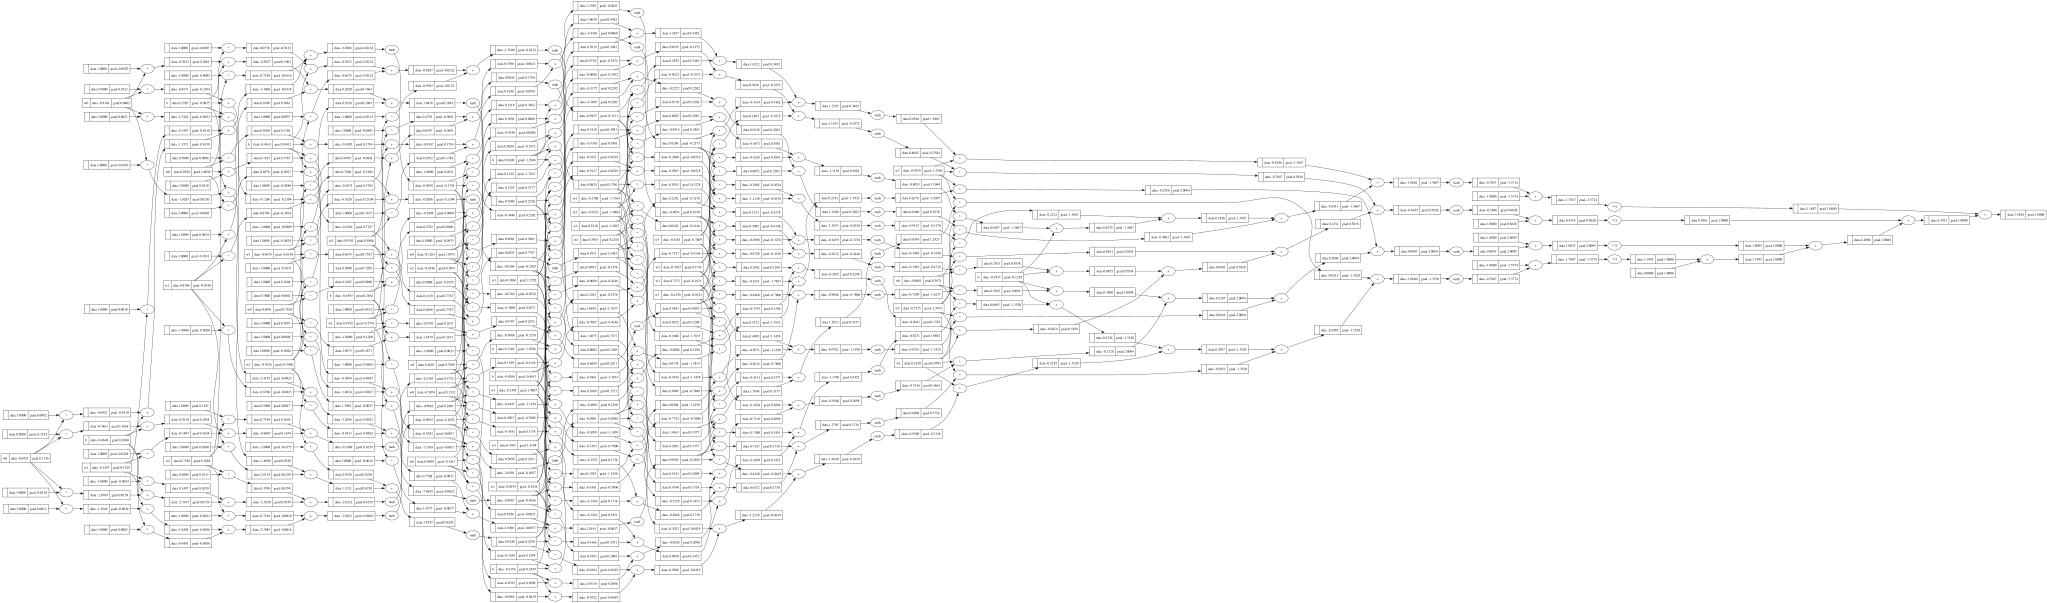

In [68]:
draw_dot(loss)